# Learning an Image Classification Model from Scratch (PyTorch)

This is the PyTorch version of the Keras [course notebook](course_notebook.ipynb). The data loading and exploration sections are identical — only the model building, training, and evaluation sections differ.

## Technical Preliminaries

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

## Load and explore the dataset

We use Keras just for the dataset download (it's the most convenient source), then work entirely in PyTorch.

In [2]:
from tensorflow.keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

In [3]:
print(x_train.shape, y_train.shape)

(60000, 28, 28) (60000,)


In [19]:
y_train[5:]

array([2, 7, 2, ..., 3, 0, 5], dtype=uint8)

There are 60,000 images in the training set, each of which is a 28x28 matrix.

In [4]:
print(x_test.shape, y_test.shape)

(10000, 28, 28) (10000,)


The remaining 10,000 images are in the test set.

In [5]:
labels = ["T-shirt/top",
          "Trouser",
          "Pullover",
          "Dress",
          "Coat",
          "Sandal",
          "Shirt",
          "Sneaker",
          "Bag",
          "Ankle boot"]

In [6]:
labels[y_train[0]]

'Ankle boot'

Let's look at the first 25 images.

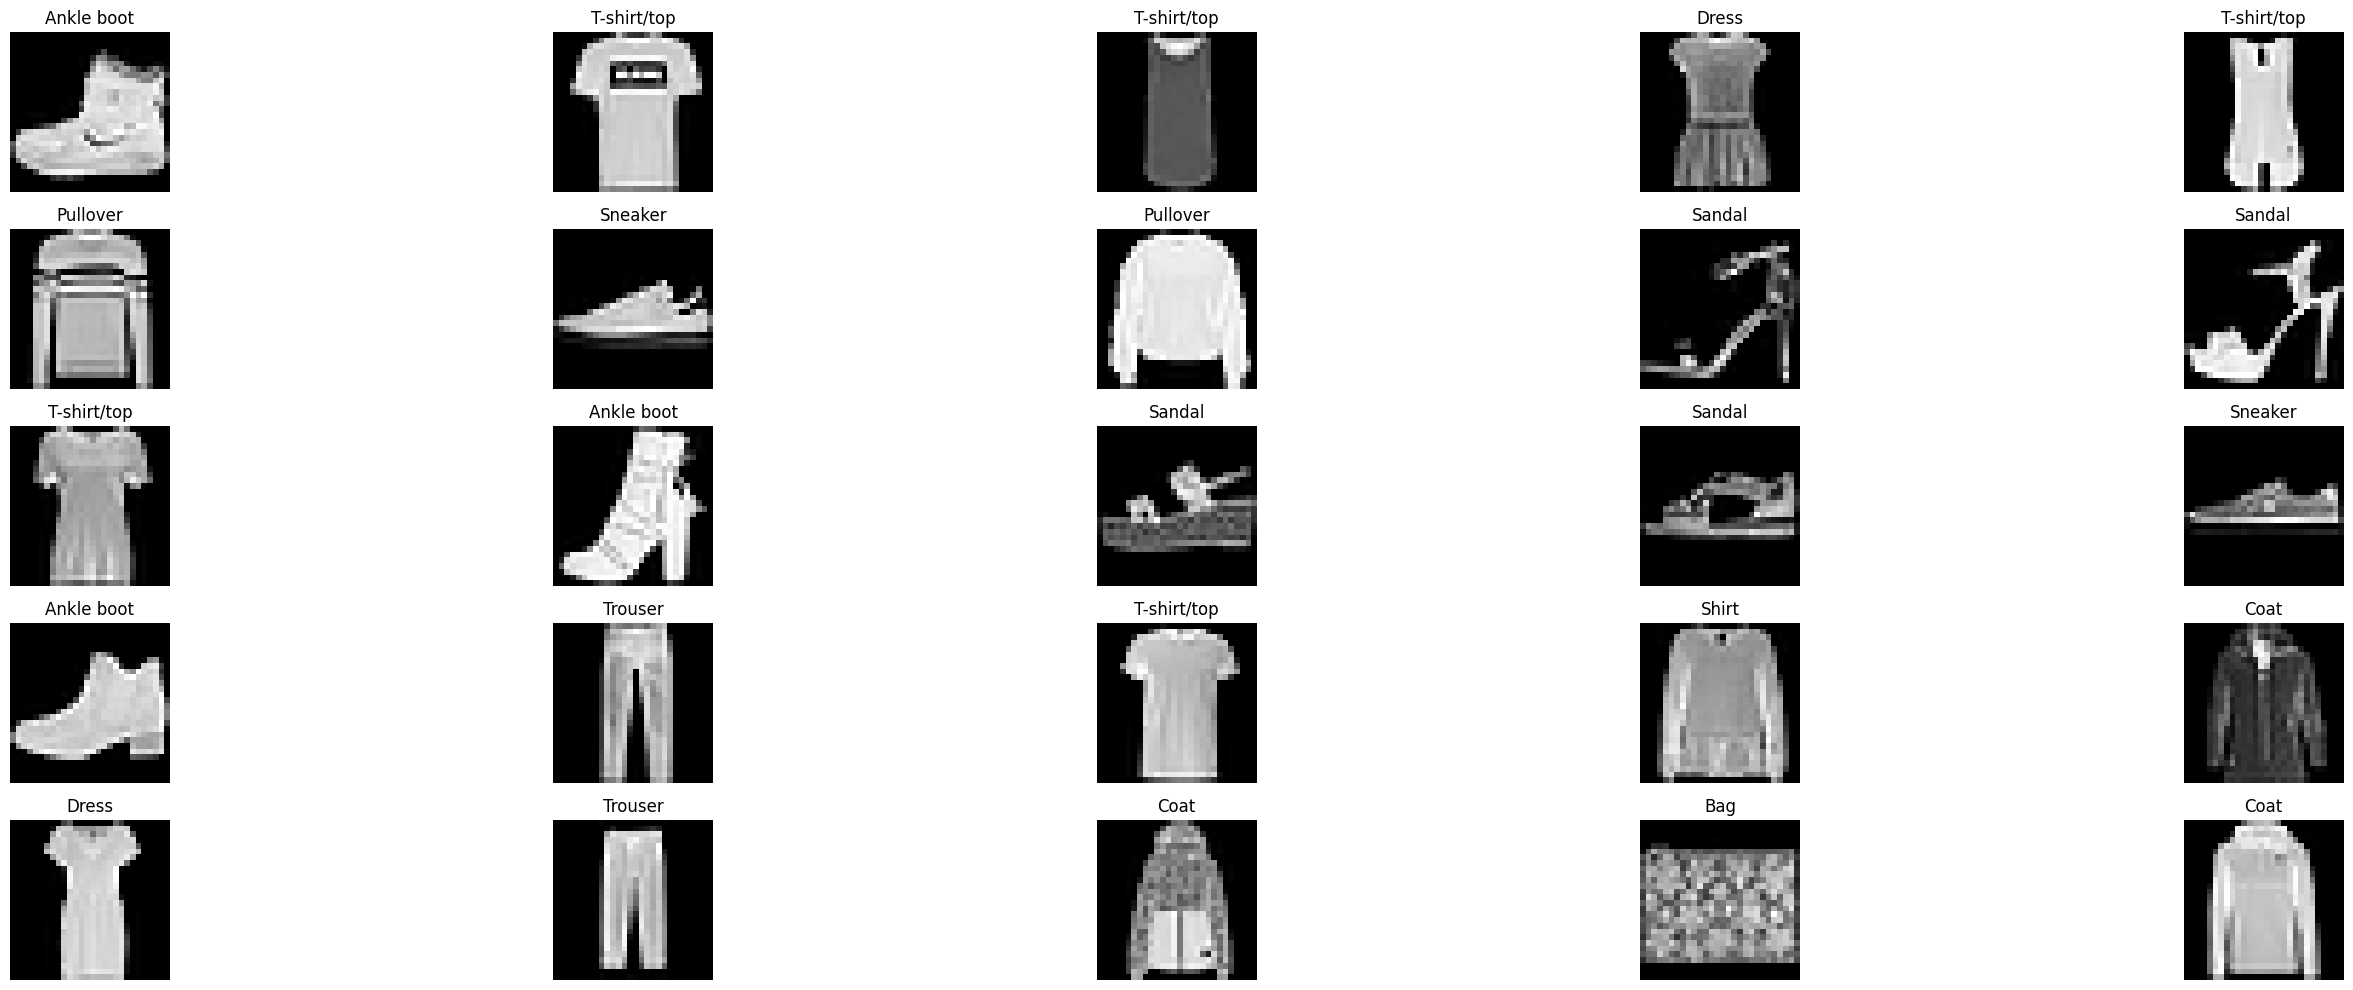

In [7]:
fig, ax = plt.subplots(5, 5, figsize=(30, 10))
for i in range(5):
    for j in range(5):
        idx = i * 5 + j
        ax[i, j].imshow(x_train[idx], cmap='gray')
        ax[i, j].set_title(labels[y_train[idx]])
        ax[i, j].axis('off')
plt.tight_layout()
plt.show()

## Data Prep

NNs learn best when each independent variable is in a small range. So, let's normalize the pixel values from [0, 255] to [0, 1].

In [8]:
x_train = x_train / 255.0
x_test = x_test / 255.0

### Convert to PyTorch tensors and create DataLoader

In [9]:
# Split training data into train and validation (80/20)
n_val = int(len(x_train) * 0.2)
x_val_t = torch.tensor(x_train[:n_val], dtype=torch.float32)
y_val_t = torch.tensor(y_train[:n_val], dtype=torch.long)
x_tr_t = torch.tensor(x_train[n_val:], dtype=torch.float32)
y_tr_t = torch.tensor(y_train[n_val:], dtype=torch.long)
x_test_t = torch.tensor(x_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

batch_size = 64
train_loader = DataLoader(TensorDataset(x_tr_t, y_tr_t), batch_size=batch_size, shuffle=True)

## Build a model

### Define model in PyTorch

We'll start with a simple one-hidden-layer model, mirroring the Keras notebook's baseline:
- Flatten the 28x28 image into a 784-long vector
- Hidden layer with 256 units and ReLU activation
- Output layer with 10 units (one per class)

Note: In PyTorch, `CrossEntropyLoss` applies softmax internally, so we don't add a softmax layer.

In [10]:
class FashionNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),   # Hidden layer: 784 -> 256
            nn.ReLU(),
            nn.Linear(256, 10),    # Output layer: 256 -> 10
        )

    def forward(self, x):
        return self.net(x)

model = FashionNet()

In [11]:
print(model)

FashionNet(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [12]:
num_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {num_params}")

Total parameters: 203530


Let's hand-calculate the number of parameters to verify.

In [13]:
(784 * 256 + 256) + (256 * 10 + 10)

203530

### Set optimization parameters

In PyTorch, we set up the loss function and optimizer as separate objects.

* **Loss function**: `nn.CrossEntropyLoss()` — combines log-softmax and NLL loss. Equivalent to Keras' `sparse_categorical_crossentropy`.
* **Optimizer**: `torch.optim.Adam` — the same Adam optimizer used in the Keras notebook.

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## Train the model

Unlike Keras where `model.fit()` handles the entire training loop, in PyTorch we write the training loop explicitly. This gives us full control over what happens at each step:

1. **Forward pass**: compute predictions
2. **Compute loss**: compare predictions to targets
3. **Backward pass**: compute gradients
4. **Update weights**: optimizer takes a step

In [15]:
num_epochs = 20

history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}

for epoch in range(num_epochs):
    # --- Training phase ---
    model.train()
    epoch_loss, epoch_correct, epoch_total = 0.0, 0, 0

    for xb, yb in train_loader:
        optimizer.zero_grad()           # reset gradients
        logits = model(xb)              # forward pass
        loss = criterion(logits, yb)    # compute loss
        loss.backward()                 # backward pass
        optimizer.step()                # update weights

        epoch_loss += loss.item() * len(xb)
        epoch_correct += (logits.argmax(1) == yb).sum().item()
        epoch_total += len(xb)

    train_loss = epoch_loss / epoch_total
    train_acc = epoch_correct / epoch_total

    # --- Validation phase ---
    model.eval()
    with torch.no_grad():
        val_logits = model(x_val_t)
        val_loss = criterion(val_logits, y_val_t).item()
        val_acc = (val_logits.argmax(1) == y_val_t).float().mean().item()

    history["loss"].append(train_loss)
    history["accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} - "
          f"loss: {train_loss:.4f} - accuracy: {train_acc:.4f} - "
          f"val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")

Epoch 1/20 - loss: 0.5476 - accuracy: 0.8094 - val_loss: 0.4303 - val_accuracy: 0.8449
Epoch 2/20 - loss: 0.3956 - accuracy: 0.8580 - val_loss: 0.3698 - val_accuracy: 0.8662
Epoch 3/20 - loss: 0.3518 - accuracy: 0.8720 - val_loss: 0.3544 - val_accuracy: 0.8708
Epoch 4/20 - loss: 0.3279 - accuracy: 0.8809 - val_loss: 0.3280 - val_accuracy: 0.8804
Epoch 5/20 - loss: 0.3071 - accuracy: 0.8879 - val_loss: 0.3168 - val_accuracy: 0.8817
Epoch 6/20 - loss: 0.2922 - accuracy: 0.8924 - val_loss: 0.3170 - val_accuracy: 0.8832
Epoch 7/20 - loss: 0.2754 - accuracy: 0.8980 - val_loss: 0.3226 - val_accuracy: 0.8821
Epoch 8/20 - loss: 0.2669 - accuracy: 0.9032 - val_loss: 0.2969 - val_accuracy: 0.8901
Epoch 9/20 - loss: 0.2547 - accuracy: 0.9051 - val_loss: 0.2921 - val_accuracy: 0.8936
Epoch 10/20 - loss: 0.2454 - accuracy: 0.9089 - val_loss: 0.2908 - val_accuracy: 0.8941
Epoch 11/20 - loss: 0.2342 - accuracy: 0.9136 - val_loss: 0.3253 - val_accuracy: 0.8856
Epoch 12/20 - loss: 0.2283 - accuracy: 0.

Let's plot the loss and accuracy curves to see if **overfitting** is going on (i.e., the model has started memorizing the training data).

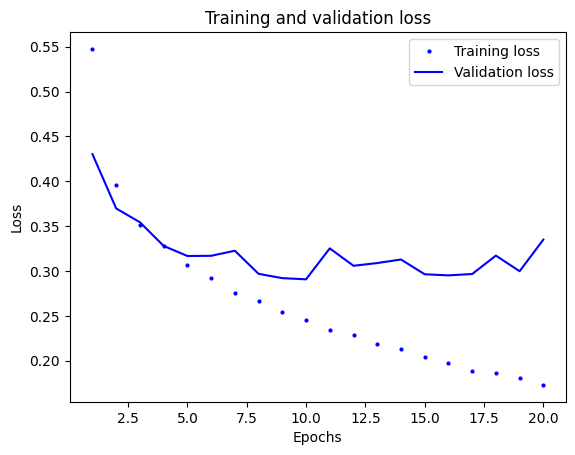

In [16]:
epochs_range = range(1, num_epochs + 1)
plt.plot(epochs_range, history["loss"], "bo", label="Training loss", markersize=2)
plt.plot(epochs_range, history["val_loss"], "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

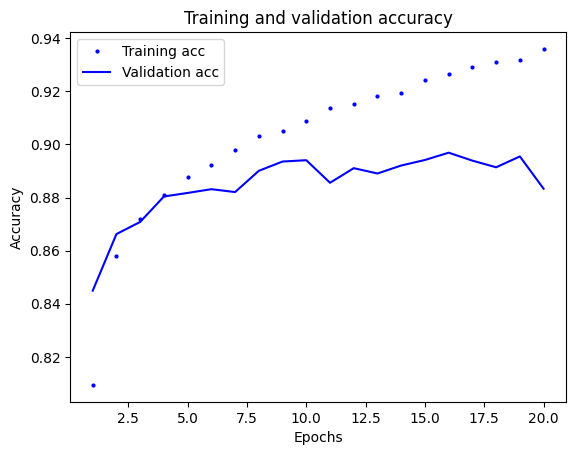

In [17]:
plt.clf()
plt.plot(epochs_range, history["accuracy"], "bo", label="Training acc", markersize=2)
plt.plot(epochs_range, history["val_accuracy"], "b", label="Validation acc")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Evaluate the model

Let's see how well the model does on the test set.

In [18]:
model.eval()
with torch.no_grad():
    test_logits = model(x_test_t)
    test_loss = criterion(test_logits, y_test_t).item()
    test_acc = (test_logits.argmax(1) == y_test_t).float().mean().item()

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Test loss: 0.3779
Test accuracy: 0.8774


In [ ]:
# pick 10 random test images (use x_test_t — the tensor — not the numpy array)
idx = np.random.choice(len(x_test_t), size=10, replace=False)
x_sample = x_test_t[idx]        # shape [10, 28, 28]
y_sample = y_test_t[idx]        # shape [10]  — true labels

# run the model (eval mode + no_grad: we're not training)
model.eval()
with torch.no_grad():
    sample_logits = model(x_sample)              # [10, 10] raw scores
    sample_probs  = sample_logits.softmax(dim=1) # -> probabilities
    preds         = sample_probs.argmax(dim=1)   # predicted class index per image
    confidence    = sample_probs.max(dim=1).values  # prob of the winning class

# plot images with predicted vs true labels
fig, ax = plt.subplots(2, 5, figsize=(15, 6))
for i in range(10):
    r, c = divmod(i, 5)
    ax[r, c].imshow(x_sample[i], cmap="gray")
    ax[r, c].axis("off")
    correct = preds[i].item() == y_sample[i].item()
    color = "green" if correct else "red"
    ax[r, c].set_title(
        f"pred: {labels[preds[i]]} ({confidence[i]:.0%})\n"
        f"true: {labels[y_sample[i]]}",
        color=color, fontsize=10,
    )
plt.tight_layout()
plt.show()

## PyTorch vs Keras: key differences

| | Keras | PyTorch |
|---|---|---|
| **Model definition** | Sequential or Functional API | Subclass `nn.Module` |
| **Training** | `model.fit()` (one line) | Explicit loop (forward, loss, backward, step) |
| **Evaluation** | `model.evaluate()` | Manual with `torch.no_grad()` |
| **Optimizer setup** | `model.compile()` | Separate `torch.optim` object |
| **Train/eval mode** | Automatic | Must call `model.train()` / `model.eval()` |
| **Loss for multi-class** | `sparse_categorical_crossentropy` | `nn.CrossEntropyLoss()` (includes softmax) |

PyTorch requires more code but gives you full visibility into the training process.